In [52]:
import pandas as pd
import numpy as np

In [53]:
df = pd.read_csv(r'C:\Users\mabin\Desktop\DataScienceClassNotes\Spam_Classifier_Project\spam.csv', encoding="latin-1")

In [54]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [55]:
df.shape

(5572, 5)

## Stages of Project
1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model building
5.  Evaulation
6. Improvement
7. Website
8. Deploy

## 1. Data Cleaning

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [57]:
# Here as you can see the last three columns has very less value most that is around 90% is empty
# so it is better to drop this three columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace= True, axis=1)

In [58]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [59]:
# Renaming the columns to a proper meaning
df.rename(columns={
    'v1' : 'target',
    'v2' : 'text'
}, inplace= True)

In [60]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [61]:
df.isnull().sum()
# As we can see there is no null values present in both columns

target    0
text      0
dtype: int64

In [62]:
df.duplicated().sum()
# There are around 403 duplicates, So the best practice is to drop them

np.int64(403)

In [63]:
df = df.drop_duplicates(keep='first')

In [64]:
df.shape

(5169, 2)

In [65]:
# Using Label encoder
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [66]:
df['target'] = encoder.fit_transform(df['target'])

In [67]:
df.head()
# Here Ham = 0 and Spam = 1

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. EDA

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

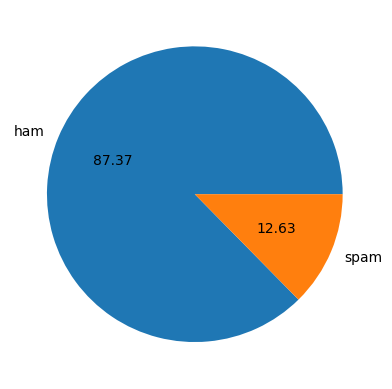

In [70]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

# It is clear is Data is Imbalanced

In [71]:
# Doing some feature engineering

import nltk

In [72]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mabin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [73]:
df['num_characters'] = df['text'].apply(len)

In [74]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [75]:
from nltk.tokenize import word_tokenize
df['num_words'] = df['text'].apply(lambda x:len(word_tokenize(x)) )

In [76]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [77]:
from nltk.tokenize import sent_tokenize
df['num_sentences'] = df['text'].apply(lambda x:len(sent_tokenize(x)))

In [78]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [79]:
# Describing the new columns
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [80]:
# Describing with respect to ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [81]:
# Describing with respect to spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

# in case of spam the number of character is very high then ham
# the number of words and number of sentences is also high in spam

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [82]:
df['num_characters'].idxmax()

np.int64(1084)

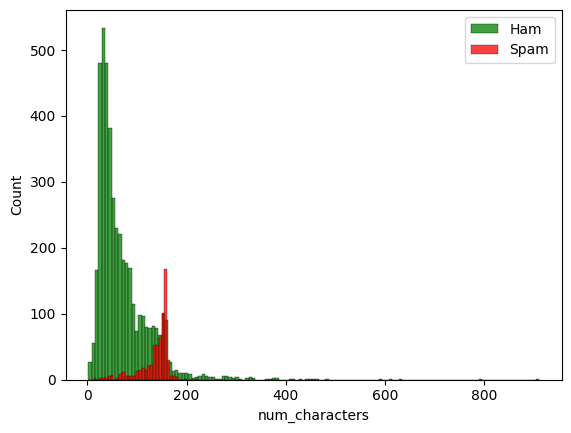

In [83]:
sns.histplot(df[df['target'] == 0]['num_characters'], color= 'green')
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')
plt.legend(['Ham','Spam'])

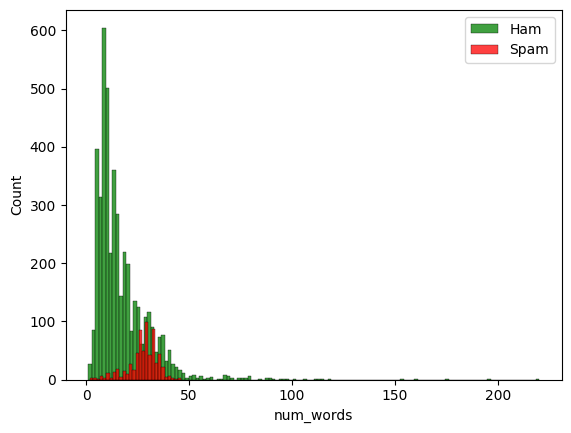

In [84]:
sns.histplot(df[df['target'] == 0]['num_words'], color= 'green')
sns.histplot(df[df['target'] == 1]['num_words'], color='red')
plt.legend(['Ham','Spam'])

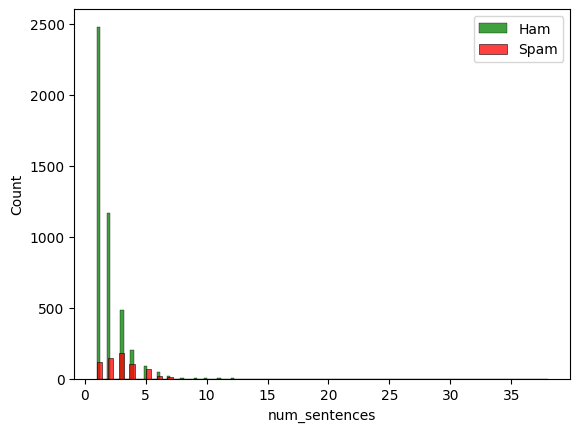

In [85]:
sns.histplot(df[df['target'] == 0]['num_sentences'], color= 'green')
sns.histplot(df[df['target'] == 1]['num_sentences'], color='red')
plt.legend(['Ham','Spam'])

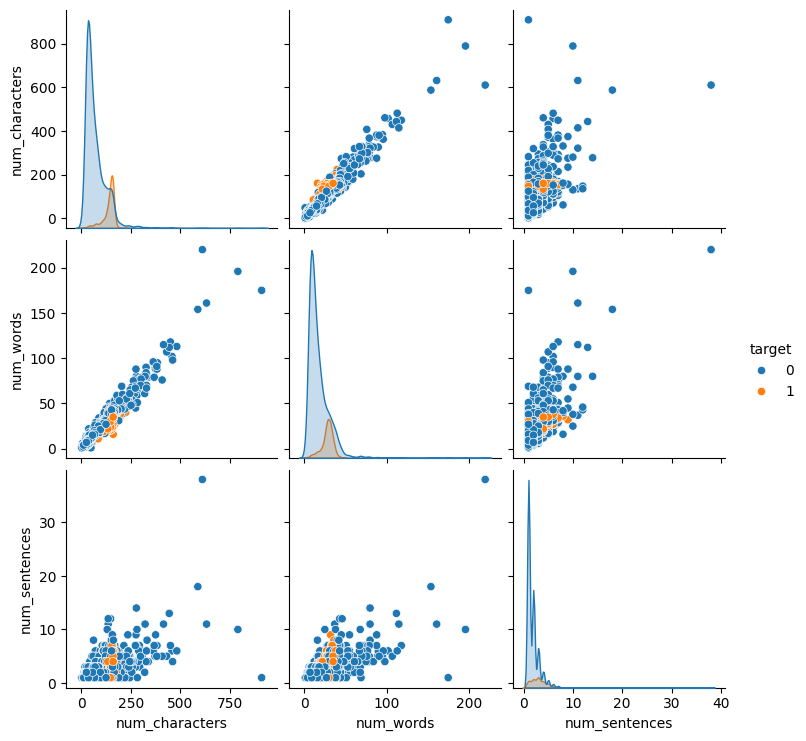

In [86]:
sns.pairplot(df, hue='target')

<Axes: >

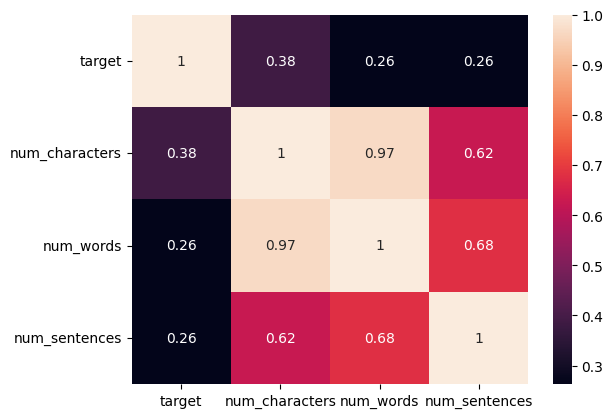

In [87]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True)

In [88]:
df.to_csv('cleaned_spam.csv',index=False)

## 3. Data Preprocessing

* Lower Case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming

In [37]:
import contractions
import re
import spacy
from bs4 import BeautifulSoup
# -- The Comprehensive Normalization Pipline --

nlp = spacy.load("en_core_web_sm")

def normilization_pipeline(text):
    """
    A more realistic pipeline to clean scraped data
    """
    
    # --- Step 1: Structural Cleaning ---
    # Remove HTML tags using BeautifulSoup
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S*@\S*\s?', '', text)
    
    # Removing special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    
    
    
    # --- Step 2: Linguistic Normalization (Pre-tokenization) ---
    # Expand contractions
    text = contractions.fix(text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    
    
    # --- Step 3: Token-based Normalization using SpaCy ---
    doc = nlp(text)
    
    clean_tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    
    clean_tokens = " ".join(clean_tokens) # To convet list into str
    # print(text)
    return clean_tokens



In [38]:
df['transformed_text'] = df['text'].apply(normilization_pipeline)

In [39]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,49,13,1,dun early hor c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf live


In [40]:
# World cloud of ham

from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='White')

In [41]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

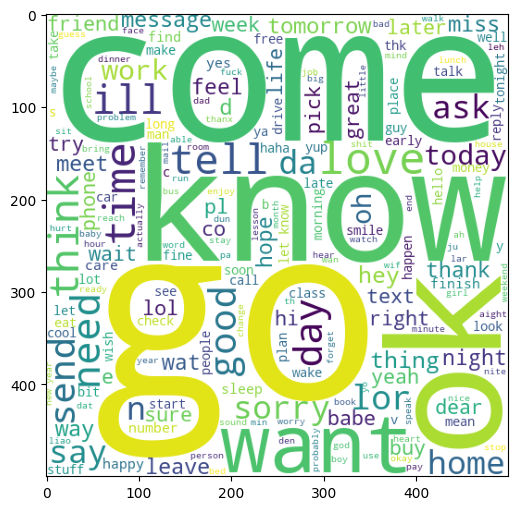

In [42]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [43]:
# World cloud of spam
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

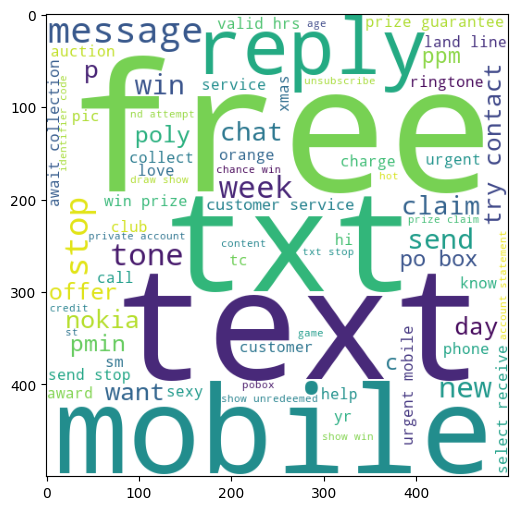

In [44]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

### Top 30 Ham words

In [45]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [46]:
len(ham_corpus)

28980

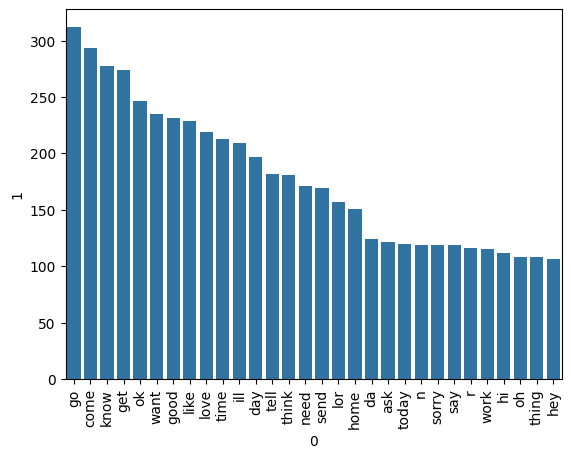

In [47]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

### Top 30 Spam words

In [48]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [49]:
len(spam_corpus)

8109

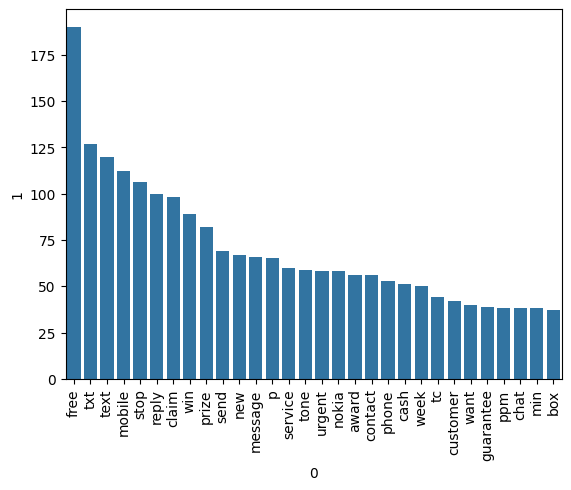

In [50]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [51]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,49,13,1,dun early hor c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf live


## 4. Model Building

In [51]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [52]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [53]:
X.shape

(5169, 7174)

In [54]:
y = df['target'].values

In [55]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

We are taking Naive Bayes because it belive that the Naive Bayes is better with Document type data

In [57]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [58]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [59]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

# --- The below reference is given by using CountVectorizer() --------
# As we can see the accuracy_score is not so bad
# but the confusion_matrix show the true positive is high but true negative is also large
# and the false positive is low but the false negative is not well
# The precision_score is very poor it is 0.42, hence the naive_bayes(GaussianNB) is not a good model to be used

0.8278529980657641
[[742 154]
 [ 24 114]]
0.4253731343283582


In [60]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

# --- The below reference is given by using CountVectorizer() --------
# Here the accuracy score is much better then GaussianNB it is nearly 0.95
# and the confusion_matrix is doing better
# The precision_score is good, still has to be better

0.9584139264990329
[[896   0]
 [ 43  95]]
1.0


In [61]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

# --- The below reference is given by using CountVectorizer() --------
# Here the accuracy score is much better then MultinomialNB it is nearly 0.95
# and the confusion_matrix is doing greate
# The precision_score better

0.965183752417795
[[889   7]
 [ 29 109]]
0.9396551724137931


After going through the naive_bayes models the best fit model is naive_bayes(MultinomialNB) using TfidfVectorizer() it has 1.0 presicion score
which is the best score we can acchive, why we are not caring about accuracy score because at the begining of this project we saw that the data is imbalanced
so the better practice it to consider the presicion score more

## Checking Other Models

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [63]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [64]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [65]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [66]:
train_classifier(svc,X_train,y_train,X_test,y_test) # Checking svc in train_classifier

(0.9690522243713733, 0.9491525423728814)

In [67]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9690522243713733
Precision -  0.9491525423728814
For  KN
Accuracy -  0.902321083172147
Precision -  1.0
For  NB
Accuracy -  0.9584139264990329
Precision -  1.0
For  DT
Accuracy -  0.9245647969052224
Precision -  0.8333333333333334
For  LR
Accuracy -  0.9516441005802708
Precision -  0.9230769230769231


c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.8974854932301741
Precision -  0.9
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.8837209302325582
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  GBDT
Accuracy -  0.9410058027079303
Precision -  0.9425287356321839
For  xgb
Accuracy -  0.965183752417795
Precision -  0.9473684210526315


In [68]:

performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [69]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.902321,1.000000
2,NB,0.958414,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.974138
0,SVC,0.969052,0.949153
10,xgb,0.965184,0.947368
9,GBDT,0.941006,0.942529
4,LR,0.951644,0.923077
6,AdaBoost,0.897485,0.900000
7,BgC,0.962282,0.883721


In [70]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [71]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.902321
1,NB,Accuracy,0.958414
2,RF,Accuracy,0.971954
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.969052
5,xgb,Accuracy,0.965184
6,GBDT,Accuracy,0.941006
7,LR,Accuracy,0.951644
8,AdaBoost,Accuracy,0.897485
9,BgC,Accuracy,0.962282


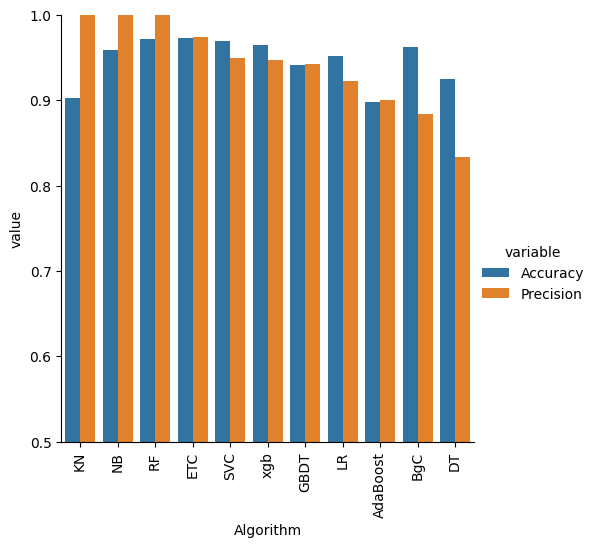

In [72]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

# Model Improve
### 1. Change the max_features parameter of TfIdf

In [73]:
tfidf2 = TfidfVectorizer(max_features=3000) # Using max 3000 features
# That means It tells the vectorizer to keep only the top 3000 most important words (features) from your entire text corpus.

X2 = tfidf2.fit_transform(df['transformed_text']).toarray()

In [74]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y_train, y_test = train_test_split(X2,y, test_size=0.2, random_state=2)


accuracy_scores2 = []
precision_scores2 = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X2_train,y_train,X2_test,y_test)
    
    # print("For ",name)
    # print("Accuracy - ",current_accuracy)
    # print("Precision - ",current_precision)
    
    accuracy_scores2.append(current_accuracy)
    precision_scores2.append(current_precision)


temp_df2 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores2,'Precision_max_ft_3000':precision_scores2}).sort_values('Precision_max_ft_3000',ascending=False)

c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### 2. Scaling the X input

In [75]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
X3 = scalar.fit_transform(X2)

In [76]:
from sklearn.model_selection import train_test_split

X3_train, X3_test, y_train, y_test = train_test_split(X3,y, test_size=0.2, random_state=2)


accuracy_scores3 = []
precision_scores3 = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X3_train,y_train,X3_test,y_test)
    
    # print("For ",name)
    # print("Accuracy - ",current_accuracy)
    # print("Precision - ",current_precision)
    
    accuracy_scores3.append(current_accuracy)
    precision_scores3.append(current_precision)


temp_df3 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores3,'Precision_scaling':precision_scores3}).sort_values('Precision_scaling',ascending=False)

c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### Merging the datasets

In [77]:
new_df = performance_df.merge(temp_df2,on='Algorithm')

In [78]:
new_df_scaled = new_df.merge(temp_df3,on='Algorithm')

### Appending the num_character col to X

In [79]:
X4 = np.hstack((X2,df['num_characters'].values.reshape(-1, 1)))
X4.shape

(5169, 3001)

In [80]:
from sklearn.model_selection import train_test_split

X4_train, X4_test, y_train, y_test = train_test_split(X4,y, test_size=0.2, random_state=2)


accuracy_scores4 = []
precision_scores4 = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X4_train,y_train,X4_test,y_test)
    
    # print("For ",name)
    # print("Accuracy - ",current_accuracy)
    # print("Precision - ",current_precision)
    
    accuracy_scores4.append(current_accuracy)
    precision_scores4.append(current_precision)
    

temp_df4 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores4,'Precision_num_chars':precision_scores4}).sort_values('Precision_num_chars',ascending=False)

c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
 

In [81]:
new_df_scaled.merge(temp_df4,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,KN,0.902321,1.000000,0.905222,0.976190,0.902321,0.951220,0.926499,0.787037
1,NB,0.958414,1.000000,0.971954,1.000000,0.972921,0.929688,0.933269,1.000000
2,RF,0.971954,1.000000,0.973888,0.974359,0.973888,0.974359,0.973888,0.991150
3,ETC,0.972921,0.974138,0.975822,0.966942,0.975822,0.966942,0.975822,0.959350
4,SVC,0.969052,0.949153,0.970019,0.957265,0.968085,0.933884,0.866538,0.000000
5,xgb,0.965184,0.947368,0.965184,0.955357,0.965184,0.955357,0.970019,0.957265
6,GBDT,0.941006,0.942529,0.942940,0.954023,0.942940,0.954023,0.945841,0.988095
7,LR,0.951644,0.923077,0.954545,0.917431,0.967118,0.940678,0.960348,0.953271
8,AdaBoost,0.897485,0.900000,0.897485,0.900000,0.897485,0.900000,0.935203,0.949367
9,BgC,0.962282,0.883721,0.967118,0.919355,0.967118,0.919355,0.971954,0.943089


# Voting Classifier

In [82]:

svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [83]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('rf', rfc)],voting='soft')

In [84]:
voting.fit(X2_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [85]:
y_pred = voting.predict(X2_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9738878143133463
Precision 0.9826086956521739


# Applying stacking

In [86]:

estimators=[('svm', svc), ('nb', mnb), ('rf', rfc)]
final_estimator=RandomForestClassifier()

In [87]:
from sklearn.ensemble import StackingClassifier

In [88]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [89]:
clf.fit(X2_train,y_train)
y_pred = clf.predict(X2_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.971953578336557
Precision 0.9224806201550387
